## ERCOT PRC Forecasting — Model Development

## 1. Problem Setup
Two models: 1h (real-time curtailment) and 24h (next-day scheduling).

Target: PRC (Physical Responsive Capability) in MW.

Use cases: Bitcoin mining, datacenter load management, battery dispatch.

In [41]:
import pandas as pd
import numpy as np
import os

PROJECT_PATH = '/Users/kamilmadey/Desktop/ercot_forecasting_project/'
processed_path = os.path.join(PROJECT_PATH, 'data', 'processed')

df = pd.read_parquet(processed_path + '/model_ready.parquet')

## 2. Classification Approach — Testing Regime Prediction

In [42]:
train = df[df['timestamp'] < '2024-01-01']     # 2021-2023
val = df[(df['timestamp'] >= '2024-01-01') & (df['timestamp'] < '2025-01-01')]  # 2024
test = df[df['timestamp'] >= '2025-01-01']      # 2025

print(train['regime'].value_counts())
print(val['regime'].value_counts())
print(test['regime'].value_counts())

regime
Normal      14387
Tight       11307
Surplus       242
Scarcity      169
Name: count, dtype: int64
regime
Normal      6636
Surplus     2104
Tight         17
Scarcity       0
Name: count, dtype: int64
regime
Surplus     5023
Normal      3374
Tight          4
Scarcity       0
Name: count, dtype: int64


In [43]:
# Train / test split - (train 2021-2024 | test on 2025) 
# Add val set for probability threshold optimization

# Need to drop RT related price cols to prevent data leakage, regime col is target col
drop_cols = ['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread']

X_train = train.drop(columns=drop_cols)
y_train = train['regime']

X_val = val.drop(columns=drop_cols)
y_val = val['regime']

X_test = test.drop(columns=drop_cols)
y_test = test['regime']

In [44]:
# 1h model - Model comparisons - Default models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix


models = {'Logistic Regression': LogisticRegression(max_iter=1000),
          'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
          'Light GBM':lgb.LGBMClassifier(n_estimators=100, random_state=42)}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"----{name}----")
    print(classification_report(y_test, y_pred))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


----Logistic Regression----
              precision    recall  f1-score   support

      Normal       0.45      0.99      0.62      3374
     Surplus       0.97      0.19      0.32      5023
       Tight       0.00      0.00      0.00         4

    accuracy                           0.51      8401
   macro avg       0.47      0.39      0.31      8401
weighted avg       0.76      0.51      0.44      8401

----Random Forest----
              precision    recall  f1-score   support

      Normal       0.40      1.00      0.57      3374
     Surplus       0.00      0.00      0.00      5023
       Tight       0.00      0.00      0.00         4

    accuracy                           0.40      8401
   macro avg       0.13      0.33      0.19      8401
weighted avg       0.16      0.40      0.23      8401



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

----Light GBM----
              precision    recall  f1-score   support

      Normal       0.40      1.00      0.57      3374
     Surplus       1.00      0.00      0.00      5023
       Tight       0.00      0.00      0.00         4

    accuracy                           0.40      8401
   macro avg       0.47      0.33      0.19      8401
weighted avg       0.76      0.40      0.23      8401



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### Finding: Concept drift makes classification unstable

Training data (2021-2023) is 63% Tight, 0.1% Surplus. 
Test data (2025) is 60% Surplus, 0% Scarcity. 

Fixed regime thresholds create class distributions that change dramatically 
over time as grid capacity grows.

Pivoting to regression — predict PRC value directly, then apply thresholds 
post-prediction. No class imbalance, no concept drift.

# Pivot to Regression

Expanding training window to mid-2024 to include higher PRC values 
that tree models need. 

Classification used 2021-2023 to expose drift; 
regression uses more data to improve predictions.

In [45]:
train = df[df['timestamp'] < '2024-07-01']     # 2021 - mid 2024
val = df[(df['timestamp'] >= '2024-07-01') & (df['timestamp'] < '2025-01-01')]  # mid-end 2024
test = df[df['timestamp'] >= '2025-01-01']      # 2025

In [46]:
X_train_reg = train.drop(columns=['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread'])
y_train_reg = train['PRC']

X_test_reg = test.drop(columns=['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread'])
y_test_reg = test['PRC']

X_val_reg = val.drop(columns=['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread'])
y_val_reg = val['PRC']

In [47]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Model comparisons - Default models

models = {'Linear Regression': LinearRegression(),
          'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
          'Light GBM':LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)}


for name, model in models.items():
    model.fit(X_train_reg, y_train_reg)
    preds = model.predict(X_test_reg)
    mae = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    
    print(f"----{name}----")
    print(f"MAE: {mae:.0f} MW | RMSE: {rmse:.0f} MW")



----Linear Regression----
MAE: 1619 MW | RMSE: 2035 MW
----Random Forest----
MAE: 2957 MW | RMSE: 3405 MW
----Light GBM----
MAE: 2690 MW | RMSE: 3132 MW


In [48]:
print(f"Train PRC mean: {y_train_reg.mean():.0f}")
print(f"Train PRC max: {y_train_reg.max():.0f}")
print(f"Test PRC mean: {y_test_reg.mean():.0f}")
print(f"Test PRC max: {y_test_reg.max():.0f}")

Train PRC mean: 5821
Train PRC max: 16357
Test PRC mean: 10620
Test PRC max: 17381


In [49]:
# Validate that Linear Regression performs better than the tree based models

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127]
}

lgbm_reg = LGBMRegressor(random_state=42, verbose=-1)
tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(lgbm_reg,param_grid=param_grid,cv=tscv, scoring="neg_mean_absolute_error")
grid.fit(X_train_reg, y_train_reg)

preds = grid.best_estimator_.predict(X_test_reg)

print(f"Best params: {grid.best_params_}")
print(f"MAE: {mean_absolute_error(y_test_reg, preds):.0f} MW ")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, preds)):.0f} MW")

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'num_leaves': 31}
MAE: 2256 MW 
RMSE: 2711 MW


### Finding: Linear Regression outperforms tree models

PRC trends upward over time due to grid capacity growth and renewable buildout. 
Train PRC mean: 5,821 MW. Test PRC mean: 10,620 MW.

Tree models cannot predict values beyond their training range — they cap 
predictions at the highest values seen in training. Even with a 
days_since_start feature, LightGBM cannot extrapolate the trend.

Linear Regression extends the trend naturally, producing lower MAE on the 
2025 holdout despite being a simpler model.

| Model | Holdout MAE |
|-------|-------------|
| Linear Regression | 1,619 MW |
| LightGBM (tuned) | 2,256 MW |

In [50]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
preds = lr.predict(X_test_reg)

bins = [0, 3000, 5000, 10000, float('inf')]
labels = ['Scarcity', 'Tight', 'Normal', 'Surplus']
predicted_regime = pd.cut(preds, bins=bins, labels=labels)
actual_regime = pd.cut(y_test_reg.values, bins=bins, labels=labels)

print(classification_report(actual_regime, predicted_regime))

              precision    recall  f1-score   support

      Normal       0.54      0.97      0.69      3374
     Surplus       0.95      0.45      0.61      5023
       Tight       0.00      0.00      0.00         4

    accuracy                           0.66      8401
   macro avg       0.50      0.47      0.43      8401
weighted avg       0.79      0.66      0.64      8401



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

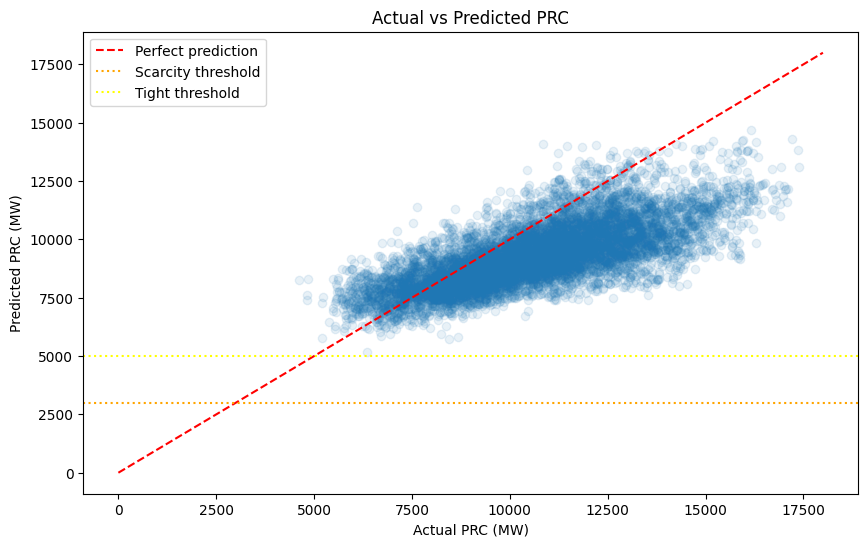

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, preds, alpha=0.1)
plt.plot([0, 18000], [0, 18000], 'r--', label='Perfect prediction')
plt.axhline(y=3000, color='orange', linestyle=':', label='Scarcity threshold')
plt.axhline(y=5000, color='yellow', linestyle=':', label='Tight threshold')
plt.xlabel('Actual PRC (MW)')
plt.ylabel('Predicted PRC (MW)')
plt.title('Actual vs Predicted PRC')
plt.legend()

### Regression Limitations

Linear Regression treats features independently. Grid stress is nonlinear, scarcity happens when low wind, high load, and high outages occur 
together. LR can't capture all of this together.

The scatter plot shows regression to the mean: overpredicts when actual PRC is low (dangerous) and underpredicts when actual PRC is high (harmless).

This motivates two improvements:
1. PRC lag features which give the model temporal memory (added into feature engineering file)
2. Ensemble (LR + LightGBM residual). LR handles trend, LGBM captures interactions

## 4. Scarcity Detection via Cross-Validation

Training (2021 - mid 2024) contains all 169 scarcity events since none occurred after September 2023. Zero scarcity in val or test means we 
can't evaluate detection on the holdout.

Using TimeSeriesSplit with 4 folds on 2021-2023 data to carve out test 
windows where scarcity events actually exist.

In [52]:
early = df[df['timestamp'] < '2024-01-01']
X_early = early.drop(columns=['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread'])
y_early = early['PRC']

tscv = TimeSeriesSplit(n_splits=4)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_early)):
    X_tr, X_te = X_early.iloc[train_idx], X_early.iloc[test_idx]
    y_tr, y_te = y_early.iloc[train_idx], y_early.iloc[test_idx]
    
    lr_fold = LinearRegression()
    lr_fold.fit(X_tr, y_tr)
    preds = lr_fold.predict(X_te)
    
    actual_regime = pd.cut(y_te, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    pred_regime = pd.cut(preds, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    
    print(f"\n--- Fold {fold+1} ---")
    print(f"Test range: {early.iloc[test_idx]['timestamp'].min().date()} → {early.iloc[test_idx]['timestamp'].max().date()}")
    print(f"Scarcity in test: {(actual_regime == 'Scarcity').sum()}")
    print(classification_report(actual_regime, pred_regime))
    print(confusion_matrix(actual_regime, pred_regime))
    mae = mean_absolute_error(y_te, preds)
    print("MAE:", mae)


--- Fold 1 ---
Test range: 2021-08-13 → 2022-03-19
Scarcity in test: 8
              precision    recall  f1-score   support

      Normal       0.54      0.88      0.67      1865
    Scarcity       0.00      0.00      0.00         8
     Surplus       0.00      0.00      0.00        10
       Tight       0.89      0.57      0.70      3338

    accuracy                           0.68      5221
   macro avg       0.36      0.36      0.34      5221
weighted avg       0.77      0.68      0.69      5221

[[1649    0    0  216]
 [   0    0    0    8]
 [   8    0    0    2]
 [1378   46    0 1914]]
MAE: 871.230597752448

--- Fold 2 ---
Test range: 2022-03-19 → 2022-10-22
Scarcity in test: 44
              precision    recall  f1-score   support

      Normal       0.54      0.84      0.66      1728
    Scarcity       0.31      0.20      0.25        44
       Tight       0.88      0.64      0.74      3449

    accuracy                           0.70      5221
   macro avg       0.58      0.56

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [53]:
from lightgbm import LGBMRegressor

lgbm_reg = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_early)):
    X_tr, X_te = X_early.iloc[train_idx], X_early.iloc[test_idx]
    y_tr, y_te = y_early.iloc[train_idx], y_early.iloc[test_idx]
    
    lgbm_reg.fit(X_tr, y_tr)
    preds = lgbm_reg.predict(X_te)
    
    actual_regime = pd.cut(y_te, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    pred_regime = pd.cut(preds, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    
    print(f"\n--- Fold {fold+1} ---")
    print(f"Scarcity in test: {(actual_regime == 'Scarcity').sum()}")
    print(classification_report(actual_regime, pred_regime))
    print(confusion_matrix(actual_regime, pred_regime))
    mae = mean_absolute_error(y_te, preds)
    print("MAE:", mae)


--- Fold 1 ---
Scarcity in test: 8
              precision    recall  f1-score   support

      Normal       0.67      0.77      0.72      1865
    Scarcity       0.00      0.00      0.00         8
     Surplus       0.00      0.00      0.00        10
       Tight       0.86      0.79      0.82      3338

    accuracy                           0.78      5221
   macro avg       0.38      0.39      0.38      5221
weighted avg       0.79      0.78      0.78      5221

[[1444    0    0  421]
 [   0    0    0    8]
 [  10    0    0    0]
 [ 711    0    0 2627]]
MAE: 643.1132494131654


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha


--- Fold 2 ---
Scarcity in test: 44
              precision    recall  f1-score   support

      Normal       0.80      0.47      0.59      1728
    Scarcity       0.00      0.00      0.00        44
       Tight       0.77      0.94      0.85      3449

    accuracy                           0.78      5221
   macro avg       0.52      0.47      0.48      5221
weighted avg       0.77      0.78      0.75      5221

[[ 809    0  919]
 [   0    0   44]
 [ 208    0 3241]]
MAE: 620.4790213616155


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha


--- Fold 3 ---
Scarcity in test: 0
              precision    recall  f1-score   support

      Normal       0.92      0.89      0.90      4179
     Surplus       0.00      0.00      0.00        36
       Tight       0.61      0.70      0.65      1006

    accuracy                           0.85      5221
   macro avg       0.51      0.53      0.52      5221
weighted avg       0.85      0.85      0.85      5221

[[3729    0  450]
 [  36    0    0]
 [ 298    0  708]]
MAE: 698.4381906278594


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha


--- Fold 4 ---
Scarcity in test: 3
              precision    recall  f1-score   support

      Normal       0.95      0.91      0.93      4870
    Scarcity       0.00      0.00      0.00         3
     Surplus       0.00      0.00      0.00       196
       Tight       0.18      0.63      0.28       152

    accuracy                           0.87      5221
   macro avg       0.28      0.39      0.30      5221
weighted avg       0.89      0.87      0.87      5221

[[4444    0    0  426]
 [   1    0    0    2]
 [ 196    0    0    0]
 [  56    0    0   96]]
MAE: 946.2871962001801


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### Finding: Both models see stress but miss the scarcity threshold

LR: 20% scarcity recall, ~1,100 MW MAE
LGBM: 0% scarcity recall, ~720 MW MAE

LR catches more scarcity because it makes larger errors in both directions, including predicting low enough to cross 3,000 MW. LGBM optimizes overall 
accuracy at the expense of tail events.

Neither model reliably detects scarcity without lag features.

## 5. PRC Lag Features

PRC has strong autocorrelation: reserves one hour ago are the best 
predictor of reserves now. Added three lag features:

- PRC_1h_lag: most recent reserve level (1h model only)
- PRC_24h_lag: same hour yesterday
- PRC_168h_lag: same hour last week

These capture the temporal momentum that raw features (load, wind, solar) 
miss. 
Grid stress develops over hours, lags let the model see that progression.

In [54]:
# Retesting with lags
# Add PRC lags
df['PRC_1h_lag'] = df['PRC'].shift(1)
df['PRC_24h_lag'] = df['PRC'].shift(24)
df['PRC_168h_lag'] = df['PRC'].shift(168)

early = df[df['timestamp'] < '2024-01-01']
early = early.dropna(subset=['PRC_1h_lag', 'PRC_24h_lag', 'PRC_168h_lag'])
X_early = early.drop(columns=['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread'])
y_early = early['PRC']

In [55]:
# Lin Reg
tscv = TimeSeriesSplit(n_splits=4)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_early)):
    X_tr, X_te = X_early.iloc[train_idx], X_early.iloc[test_idx]
    y_tr, y_te = y_early.iloc[train_idx], y_early.iloc[test_idx]
    
    lr_fold = LinearRegression()
    lr_fold.fit(X_tr, y_tr)
    preds = lr_fold.predict(X_te)
    
    actual_regime = pd.cut(y_te, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    pred_regime = pd.cut(preds, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    
    print(f"\n--- Fold {fold+1} ---")
    print(f"Test range: {early.iloc[test_idx]['timestamp'].min().date()} → {early.iloc[test_idx]['timestamp'].max().date()}")
    print(f"Scarcity in test: {(actual_regime == 'Scarcity').sum()}")
    print(classification_report(actual_regime, pred_regime))
    print(confusion_matrix(actual_regime, pred_regime))
    mae = mean_absolute_error(y_te, preds)
    print("MAE:", mae)


--- Fold 1 ---
Test range: 2021-08-19 → 2022-03-23
Scarcity in test: 8
              precision    recall  f1-score   support

      Normal       0.79      0.91      0.85      1868
    Scarcity       0.14      0.25      0.18         8
     Surplus       1.00      0.90      0.95        10
       Tight       0.94      0.86      0.90      3301

    accuracy                           0.88      5187
   macro avg       0.72      0.73      0.72      5187
weighted avg       0.89      0.88      0.88      5187

[[1702    0    0  166]
 [   0    2    0    6]
 [   1    0    9    0]
 [ 440   12    0 2849]]
MAE: 314.25440385285987

--- Fold 2 ---
Test range: 2022-03-23 → 2022-10-25
Scarcity in test: 44
              precision    recall  f1-score   support

      Normal       0.87      0.87      0.87      1752
    Scarcity       0.30      0.45      0.36        44
       Tight       0.92      0.92      0.92      3391

    accuracy                           0.90      5187
   macro avg       0.70      0.

In [56]:
lgbm_reg = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_early)):
    X_tr, X_te = X_early.iloc[train_idx], X_early.iloc[test_idx]
    y_tr, y_te = y_early.iloc[train_idx], y_early.iloc[test_idx]
    
    lgbm_reg.fit(X_tr, y_tr)
    preds = lgbm_reg.predict(X_te)
    
    actual_regime = pd.cut(y_te, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    pred_regime = pd.cut(preds, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    
    print(f"\n--- Fold {fold+1} ---")
    print(f"Scarcity in test: {(actual_regime == 'Scarcity').sum()}")
    print(classification_report(actual_regime, pred_regime))
    print(confusion_matrix(actual_regime, pred_regime))
    mae = mean_absolute_error(y_te, preds)
    print("MAE:", mae)


--- Fold 1 ---
Scarcity in test: 8
              precision    recall  f1-score   support

      Normal       0.88      0.82      0.85      1868
    Scarcity       0.50      0.12      0.20         8
     Surplus       0.00      0.00      0.00        10
       Tight       0.90      0.94      0.92      3301

    accuracy                           0.89      5187
   macro avg       0.57      0.47      0.49      5187
weighted avg       0.89      0.89      0.89      5187

[[1541    0    0  327]
 [   0    1    0    7]
 [  10    0    0    0]
 [ 205    1    0 3095]]
MAE: 285.8268426543381


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha


--- Fold 2 ---
Scarcity in test: 44
              precision    recall  f1-score   support

      Normal       0.94      0.79      0.85      1752
    Scarcity       0.62      0.18      0.28        44
       Tight       0.89      0.97      0.93      3391

    accuracy                           0.90      5187
   macro avg       0.81      0.65      0.69      5187
weighted avg       0.90      0.90      0.90      5187

[[1379    0  373]
 [   0    8   36]
 [  95    5 3291]]
MAE: 275.17292881054186

--- Fold 3 ---
Scarcity in test: 0
              precision    recall  f1-score   support

      Normal       0.94      0.95      0.95      4141
     Surplus       1.00      0.03      0.05        36
       Tight       0.80      0.80      0.80      1010

    accuracy                           0.91      5187
   macro avg       0.91      0.59      0.60      5187
weighted avg       0.91      0.91      0.91      5187

[[3934    0  207]
 [  35    1    0]
 [ 202    0  808]]
MAE: 296.2256474299326

--- Fol

## PRC Lag Features — Key Improvement

| Model | MAE Before Lags | MAE After Lags | Fold 2 Scarcity Recall Before | After |
|-------|----------------|----------------|------------------------------|-------|
| LR    | ~1,100         | ~300           | 20%                          | 45%   |
| LGBM  | ~720           | ~290           | 0%                           | 18%   |

PRC lags reduced MAE by ~65%. Linear regression has better scarcity recall (45% vs 18%) 
despite slightly worse MAE. LightGBM optimizes overall accuracy at the expense of tail events.

Using Linear Regression as primary model — scarcity detection matters more than marginal MAE.

In [65]:
# Final 1h model with lags
train = df[df['timestamp'] < '2024-07-01']
val = df[(df['timestamp'] >= '2024-07-01') & (df['timestamp'] < '2025-01-01')]
test = df[df['timestamp'] >= '2025-01-01']

drop_cols = ['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread']

X_train = train.drop(columns=drop_cols).dropna()
y_train = train.loc[X_train.index, 'PRC']

X_test = test.drop(columns=drop_cols).dropna()
y_test = test.loc[X_test.index, 'PRC']

lr_1h = LinearRegression()
lr_1h.fit(X_train, y_train)
preds = lr_1h.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, preds):.0f} MW")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.0f} MW")

MAE: 689 MW
RMSE: 1050 MW


In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

              precision    recall  f1-score   support

      Normal       0.85      0.86      0.85      3374
     Surplus       0.90      0.90      0.90      5023
       Tight       0.00      0.00      0.00         4

    accuracy                           0.88      8401
   macro avg       0.58      0.58      0.58      8401
weighted avg       0.88      0.88      0.88      8401



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

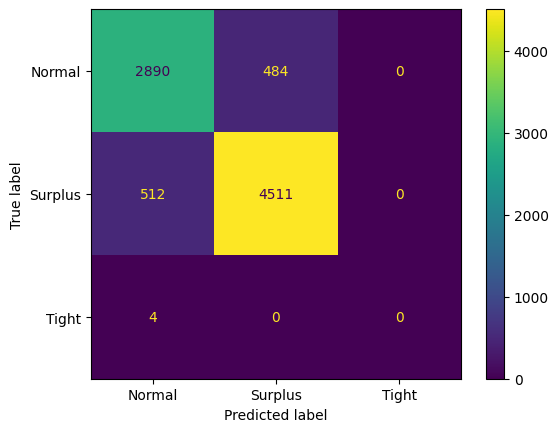

In [67]:
bins = [0, 3000, 5000, 10000, float('inf')]
labels = ['Scarcity', 'Tight', 'Normal', 'Surplus']
predicted_regime = pd.cut(preds, bins=bins, labels=labels)
actual_regime = pd.cut(y_test.values, bins=bins, labels=labels)

print(classification_report(actual_regime, predicted_regime))
ConfusionMatrixDisplay.from_predictions(actual_regime, predicted_regime)

### 1h LR with Lags — Holdout Results
MAE: 689 MW. Normal/Surplus well-separated. 

4 Tight hours misclassified as Normal, but 4 events is too few to evaluate. Scarcity recall from CV: 41%.

## 6. Ensemble Architecture — 1h Model

Linear Regression predicts PRC. Then calculate residuals. 
Train LightGBM on those residuals to learn when and how much LR misses.

At prediction time:
- LR predicts: 3,700 MW (trend-based estimate)
- LGBM predicts correction: -600 MW (nonlinear interaction detected)  
- Final: 3,700 + (-600) = 3,100 MW

LR handles extrapolation. LGBM handles interactions. Each model does what it's best at. The tree doesn't need to extrapolate because it's 
only predicting small corrections around zero, not the full PRC value.

In [68]:
lr_preds_train = lr_1h.predict(X_train)
residuals = y_train - lr_preds_train

lgbm_residual = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
lgbm_residual.fit(X_train, residuals)

ensemble_preds = lr_1h.predict(X_test) + lgbm_residual.predict(X_test)
print(f"Ensemble MAE: {mean_absolute_error(y_test, ensemble_preds):.0f} MW")

Ensemble MAE: 587 MW


In [69]:
bins = [0, 3000, 5000, 10000, float('inf')]
labels = ['Scarcity', 'Tight', 'Normal', 'Surplus']
predicted_regime = pd.cut(ensemble_preds, bins=bins, labels=labels)
actual_regime = pd.cut(y_test.values, bins=bins, labels=labels)

print(classification_report(actual_regime, predicted_regime))

              precision    recall  f1-score   support

      Normal       0.85      0.91      0.88      3374
     Surplus       0.94      0.89      0.91      5023
       Tight       0.00      0.00      0.00         4

    accuracy                           0.90      8401
   macro avg       0.60      0.60      0.60      8401
weighted avg       0.90      0.90      0.90      8401



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [70]:
tscv = TimeSeriesSplit(n_splits=4)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_early)):
    X_tr, X_te = X_early.iloc[train_idx], X_early.iloc[test_idx]
    y_tr, y_te = y_early.iloc[train_idx], y_early.iloc[test_idx]
    
    lr_fold = LinearRegression()
    lr_fold.fit(X_tr, y_tr)
    lr_preds_tr = lr_fold.predict(X_tr)
    residuals = y_tr - lr_preds_tr
    
    lgbm_res = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
    lgbm_res.fit(X_tr, residuals)
    
    preds = lr_fold.predict(X_te) + lgbm_res.predict(X_te)
    
    actual_regime = pd.cut(y_te, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    pred_regime = pd.cut(preds, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    
    print(f"\n--- Fold {fold+1} ---")
    print(f"Scarcity in test: {(actual_regime == 'Scarcity').sum()}")
    print(classification_report(actual_regime, pred_regime))
    print(f"MAE: {mean_absolute_error(y_te, preds):.0f}")


--- Fold 1 ---
Scarcity in test: 8
              precision    recall  f1-score   support

      Normal       0.83      0.88      0.85      1868
    Scarcity       0.29      0.25      0.27         8
     Surplus       1.00      0.90      0.95        10
       Tight       0.93      0.90      0.91      3301

    accuracy                           0.89      5187
   macro avg       0.76      0.73      0.74      5187
weighted avg       0.89      0.89      0.89      5187

MAE: 291

--- Fold 2 ---
Scarcity in test: 44
              precision    recall  f1-score   support

      Normal       0.93      0.80      0.86      1752
    Scarcity       0.50      0.34      0.41        44
       Tight       0.90      0.97      0.93      3391

    accuracy                           0.91      5187
   macro avg       0.78      0.70      0.73      5187
weighted avg       0.91      0.91      0.90      5187

MAE: 269

--- Fold 3 ---
Scarcity in test: 0
              precision    recall  f1-score   support

  

## Ensemble Model (LR + LightGBM Residual)

Linear regression captures PRC trend. LightGBM corrects residual errors 
from nonlinear feature interactions.

Holdout (2025): MAE 587 MW, 90% weighted F1
CV Fold 2 (2022): MAE 269 MW, 41% scarcity recall, 91% overall accuracy

Improvement over LR alone: 15% MAE reduction, better Normal/Surplus 
separation while maintaining scarcity detection.

## Saving the Ensemble model

In [71]:
import joblib

# Ensemble is two models — save both
joblib.dump(lr_1h, PROJECT_PATH + 'models/lr_1h_prc.pkl')
joblib.dump(lgbm_residual, PROJECT_PATH + 'models/lgbm_1h_residual.pkl')

['/Users/kamilmadey/Desktop/ercot_forecasting_project/models/lgbm_1h_residual.pkl']

## 24 hour model

Fewer features available 24 hours ahead, no real-time actuals, no 1h lags, no 6h rolling stats, no ramp rates. 

Model relies on forecasts, 24h/168h lags, and time features.

In [72]:
drop_24h = [
    # Target and metadata
    'timestamp', 'PRC', 'regime',
    # Prices (used for backtesting, not prediction)
    'RT_price', 'DAM_price', 'RT_DAM_spread',
    # Real-time actuals (not known 24h ahead)
    'hub_load', 'load_total',
    'WGRPP_LZ_WEST', 'WGRPP_SYSTEM_WIDE',
    'PVGRPP_SYSTEM_WIDE',
    # Derived from actuals (not available)
    'net_load_system', 'net_load_west',
    'renewable_pct_system', 'renewable_pct_west',
    'wind_forecast_error', 'solar_forecast_error',
    # 1h lags (not available 24h ahead)
    'RT_1h_lag', 'DAM_1h_lag', 'PRC_1h_lag',
    # 6h rolling stats (too recent)
    'RT_price_roll_mean_6h', 'RT_price_roll_std_6h',
    'DAM_price_roll_mean_6h', 'DAM_price_roll_std_6h',
    'hub_load_roll_mean_6h', 'hub_load_roll_std_6h',
    'load_total_roll_mean_6h', 'load_total_roll_std_6h',
    'WGRPP_LZ_WEST_roll_mean_6h', 'WGRPP_LZ_WEST_roll_std_6h',
    # Ramp rates (need current hour)
    'load_total_ramp', 'hub_load_ramp',
    'wind_west_ramp', 'wind_system_ramp',
    'RT_price_ramp'
]

X_train_24h = train.drop(columns=drop_24h).dropna()
y_train_24h = train.loc[X_train_24h.index, 'PRC']

X_test_24h = test.drop(columns=drop_24h).dropna()
y_test_24h = test.loc[X_test_24h.index, 'PRC']

X_val_24h = val.drop(columns=drop_24h).dropna()
y_val_24h = val.loc[X_val_24h.index, 'PRC']

## Baseline comparison


In [73]:
## 24 h model

models_24h = {
    'Linear Regression': LinearRegression(),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
}

for name, model in models_24h.items():
    model.fit(X_train_24h, y_train_24h)
    preds = model.predict(X_test_24h)
    print(f"----{name}----")
    print(f"MAE: {mean_absolute_error(y_test_24h, preds):.0f} MW")

----Linear Regression----
MAE: 1359 MW
----LightGBM----
MAE: 2143 MW


In [74]:
lr_24h = LinearRegression()
lr_24h.fit(X_train_24h, y_train_24h)
preds_24h = lr_24h.predict(X_test_24h)

In [75]:
# Ensemble

lr_24h = LinearRegression()
lr_24h.fit(X_train_24h, y_train_24h)
lr_preds_train_24h = lr_24h.predict(X_train_24h)
residuals_24h = y_train_24h - lr_preds_train_24h

lgbm_residual_24h = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
lgbm_residual_24h.fit(X_train_24h, residuals_24h)

ensemble_preds_24h = lr_24h.predict(X_test_24h) + lgbm_residual_24h.predict(X_test_24h)
print(f"24h Ensemble MAE: {mean_absolute_error(y_test_24h, ensemble_preds_24h):.0f} MW")

24h Ensemble MAE: 1528 MW


### Finding: LR wins again, ensemble adds noise
LR: 1,359 MW | LGBM: 2,143 MW | Ensemble: 1,528 MW
Tree corrections hurt — not enough signal in reduced feature set.
Using standalone LR for 24h.

In [76]:
early = df[df['timestamp'] < '2024-01-01']
early = early.dropna(subset=['PRC_24h_lag', 'PRC_168h_lag'])
X_early_24h = early.drop(columns=drop_24h, errors='ignore')
y_early_24h = early['PRC']

tscv = TimeSeriesSplit(n_splits=4)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_early_24h)):
    X_tr, X_te = X_early_24h.iloc[train_idx], X_early_24h.iloc[test_idx]
    y_tr, y_te = y_early_24h.iloc[train_idx], y_early_24h.iloc[test_idx]
    
    lr_fold = LinearRegression()
    lr_fold.fit(X_tr, y_tr)
    preds = lr_fold.predict(X_te)
    
    actual_regime = pd.cut(y_te, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    pred_regime = pd.cut(preds, bins=[0,3000,5000,10000,float('inf')], labels=['Scarcity','Tight','Normal','Surplus'])
    
    print(f"\n--- Fold {fold+1} ---")
    print(f"Scarcity in test: {(actual_regime == 'Scarcity').sum()}")
    print(classification_report(actual_regime, pred_regime))
    print(f"MAE: {mean_absolute_error(y_te, preds):.0f}")


--- Fold 1 ---
Scarcity in test: 8
              precision    recall  f1-score   support

      Normal       0.53      0.85      0.66      1868
    Scarcity       0.00      0.00      0.00         8
     Surplus       0.00      0.00      0.00        10
       Tight       0.87      0.58      0.69      3301

    accuracy                           0.67      5187
   macro avg       0.35      0.36      0.34      5187
weighted avg       0.75      0.67      0.68      5187

MAE: 940

--- Fold 2 ---
Scarcity in test: 44
              precision    recall  f1-score   support

      Normal       0.67      0.74      0.70      1752
    Scarcity       0.09      0.07      0.08        44
       Tight       0.84      0.81      0.82      3391

    accuracy                           0.78      5187
   macro avg       0.53      0.54      0.53      5187
weighted avg       0.78      0.78      0.78      5187

MAE: 571

--- Fold 3 ---
Scarcity in test: 0
              precision    recall  f1-score   support

  

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## 24h Model Results

Linear Regression: MAE 1,359 MW (winner)
LightGBM: MAE 2,143 MW
Ensemble: MAE 1,528 MW (adds noise, not signal)

CV Fold 2: 8% scarcity recall — 24h model useful for planning, not scarcity detection.

Using standalone LR for 24h. Fewer real-time features means less signal 
for tree-based corrections.

In [77]:
# Save 24h model
joblib.dump(lr_24h, PROJECT_PATH + 'models/lr_24h_prc.pkl')

['/Users/kamilmadey/Desktop/ercot_forecasting_project/models/lr_24h_prc.pkl']

## Overfitting Check

| Model | Train MAE | Test MAE | Ratio |
|-------|-----------|----------|-------|
| 1h Ensemble | 205 MW | 587 MW | 2.9x |
| 24h LR | 635 MW | 1,359 MW | 2.1x |

Gap is driven by two factors:
1. Distribution shift — test PRC (mean 10,620 MW) is nearly double 
   training PRC (mean 5,821 MW) due to grid capacity growth
2. 1h ensemble's LGBM component slightly overfits training residuals

The 24h model has a healthier ratio (2.1x) since pure LR doesn't 
overfit. Both models would improve with more recent training data 
as the grid continues evolving.

In [78]:
train_preds_1h = lr_1h.predict(X_train) + lgbm_residual.predict(X_train)
print(f"1h Train MAE: {mean_absolute_error(y_train, train_preds_1h):.0f}")
print(f"1h Test MAE: {mean_absolute_error(y_test, ensemble_preds):.0f}")

train_preds_24h = lr_24h.predict(X_train_24h)
print(f"24h Train MAE: {mean_absolute_error(y_train_24h, train_preds_24h):.0f}")
print(f"24h Test MAE: {mean_absolute_error(y_test_24h, preds_24h):.0f}")

1h Train MAE: 204
1h Test MAE: 587
24h Train MAE: 635
24h Test MAE: 1359


## Winning Models

| Horizon | Model | Holdout MAE | CV Scarcity Recall | Use Case |
|---------|-------|-------------|-------------------|----------|
| 1h | LR + LGBM Ensemble | 587 MW | 41% | Real-time curtailment |
| 24h | Linear Regression | 1,359 MW | 8% | Next-day scheduling |

1h model detects stress and acts. 24h model plans ahead but can't predict surprises.

## Feature Importance

Top 10 LR features:
renewable_pct_system    606.255872
hour_sin                115.616996
temperature              10.746301
renewable_pct_west        8.678330
precipitation             6.590911
is_weekend                5.226922
windspeed                 3.360523
month                     2.721948
hour_cos                  1.991072
humidity                  1.118199
dtype: float64


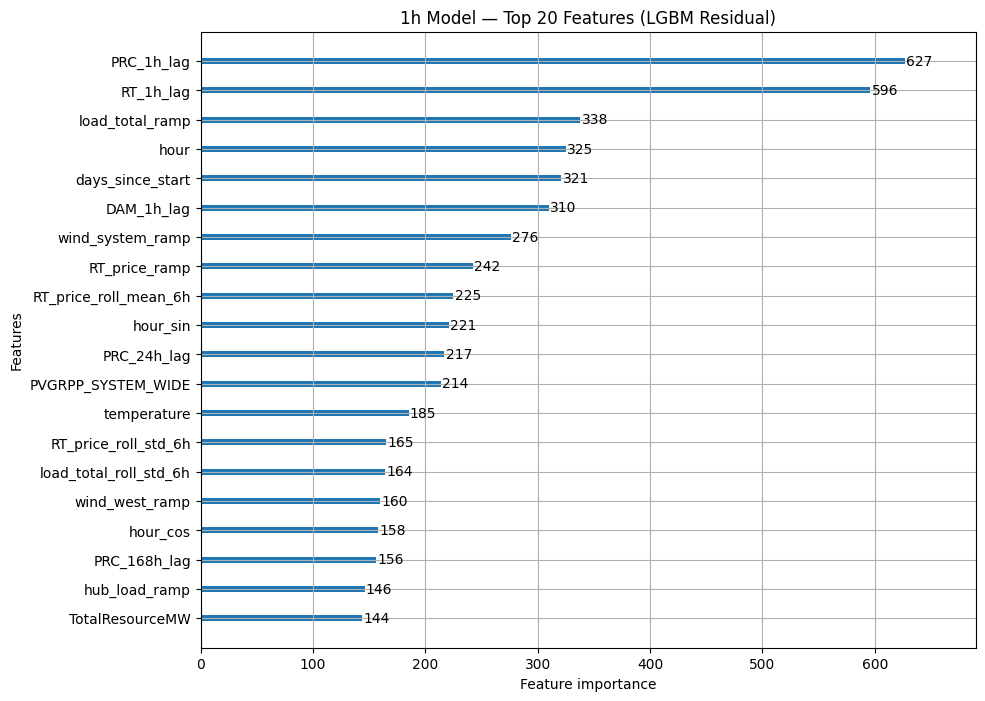

In [79]:
# 1h Ensemble — LGBM residual component shows what corrections it learned
import lightgbm as lgb

fig, ax = plt.subplots(figsize=(10, 8))
lgb.plot_importance(lgbm_residual, max_num_features=20, ax=ax)
ax.set_title('1h Model — Top 20 Features (LGBM Residual)')

# LR coefficients
lr_importance = pd.Series(lr_1h.coef_, index=X_train.columns).abs().sort_values(ascending=False)
print("Top 10 LR features:")
print(lr_importance.head(10))

In [80]:
# 24h model
lr_importance_24h = pd.Series(lr_24h.coef_, index=X_train_24h.columns).abs().sort_values(ascending=False)
print("Top 10 24h LR features:")
print(lr_importance_24h.head(10))

Top 10 24h LR features:
hour_cos            105.057885
hour_sin            101.020800
temperature          23.119173
precipitation        17.017041
is_weekend           16.947013
day_of_week          13.956793
hour                  6.365229
month                 4.000841
windspeed             3.263268
days_since_start      0.835259
dtype: float64


### Feature Importance — Key Insights

**1h LGBM Residual** — what LR gets wrong:
- `PRC_1h_lag` dominates — recent reserve level is the strongest signal 
  for corrections. When PRC is dropping fast, LR misses it but LGBM catches it.
- `RT_1h_lag` — recent price confirms stress conditions
- `days_since_start` — LGBM is learning the trend that LR partially captures
- Ramp features (`load_total_ramp`, `wind_system_ramp`) — sudden changes 
  that LR's linear assumptions miss
- `hour` — time-of-day effects on grid stress

**1h LR** — what drives the trend prediction:
- `renewable_pct_system` — highest coefficient by far. More renewables = more reserves.
  This single feature captures the structural grid evolution.
- Time features (hour_sin, temperature) — daily and seasonal patterns

**24h LR** — fundamentals-driven without real-time data:
- Time features dominate (hour_cos, hour_sin) — daily cycle is the 
  strongest 24h-ahead signal
- Weather (temperature, precipitation) — next-day stress predictor
- No PRC or price lags in top features — confirms 24h model relies 
  on physical fundamentals, not momentum

This aligns with market reality: real-time decisions use momentum (lags), 
day-ahead planning uses fundamentals (weather, time patterns).

## Backtesting 

In [81]:
# Must add these before

# Recreate splits
train = df[df['timestamp'] < '2024-07-01']
val = df[(df['timestamp'] >= '2024-07-01') & (df['timestamp'] < '2025-01-01')]
test = df[df['timestamp'] >= '2025-01-01']

drop_cols = ['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread']

X_val = val.drop(columns=drop_cols).dropna()[X_train.columns]
X_val_24h = val.drop(columns=drop_24h, errors='ignore').dropna()[X_train_24h.columns]

In [82]:
import sys
sys.path.append(PROJECT_PATH + 'src/models/')
from decision_layer import mining_backtest, datacenter_backtest, optimize_thresholds


# Val predictions for threshold optimization
val_preds_1h = lr_1h.predict(X_val) + lgbm_residual.predict(X_val)
val_preds_24h = lr_24h.predict(X_val_24h)

# Test predictions
test_preds_1h = lr_1h.predict(X_test) + lgbm_residual.predict(X_test)
test_preds_24h = lr_24h.predict(X_test_24h)

# Optimize thresholds on val
best_mining_1h, _ = optimize_thresholds(val, val_preds_1h, mining_backtest)
best_mining_24h, _ = optimize_thresholds(val, val_preds_24h, mining_backtest)
best_dc_1h, _ = optimize_thresholds(val, val_preds_1h, datacenter_backtest)
best_dc_24h, _ = optimize_thresholds(val, val_preds_24h, datacenter_backtest)

# Save thresholds
import json
thresholds = {
    'mining_1h': best_mining_1h,
    'mining_24h': best_mining_24h,
    'datacenter_1h': best_dc_1h,
    'datacenter_24h': best_dc_24h
}
with open(PROJECT_PATH + 'models/thresholds.json', 'w') as f:
    json.dump(thresholds, f)

print(f"1h Mining thresholds: {best_mining_1h}")
print(f"24h Mining thresholds: {best_mining_24h}")
print(f"1h Datacenter thresholds: {best_dc_1h}")
print(f"24h Datacenter thresholds: {best_dc_24h}")


1h Mining thresholds: {'tight_threshold': 6750, 'scarcity_threshold': 2000}
24h Mining thresholds: {'tight_threshold': 6750, 'scarcity_threshold': 2000}
1h Datacenter thresholds: {'tight_threshold': 6750, 'scarcity_threshold': 2000}
24h Datacenter thresholds: {'tight_threshold': 6500, 'scarcity_threshold': 2000}


In [83]:
print("=== Mining 1h ===")
mining_1h = mining_backtest(test, test_preds_1h, **best_mining_1h)

print("\n=== Mining 24h ===")
mining_24h = mining_backtest(test, test_preds_24h, **best_mining_24h)

print("\n=== Datacenter 1h ===")
dc_1h = datacenter_backtest(test, test_preds_1h, **best_dc_1h)

print("\n=== Datacenter 24h ===")
dc_24h = datacenter_backtest(test, test_preds_24h, **best_dc_24h)

=== Mining 1h ===
Always-on cost: $-10,797,056
Model-guided cost: $-11,753,026
Savings: $955,970
Hours curtailed: 159 / 8401

=== Mining 24h ===
Always-on cost: $-10,797,056
Model-guided cost: $-11,084,037
Savings: $286,982
Hours curtailed: 50 / 8401

=== Datacenter 1h ===
Always-on cost: $56,410,944
Model-guided cost: $56,299,300
Savings: $111,645
Hours at reduced load: 159 / 8401

=== Datacenter 24h ===
Always-on cost: $56,410,944
Model-guided cost: $56,399,173
Savings: $11,771
Hours at reduced load: 25 / 8401


## Backtest on Stress Period (2022)

2025 had zero scarcity events — model correctly avoided over-curtailing.
To evaluate economic value during actual grid stress, backtesting on 
CV Fold 2 (March-October 2022) which contains 44 scarcity events. 
These are out-of-sample predictions — the model never trained on this period.

In [84]:
# Generate fold 2 predictions for 1h backtest
early = df[df['timestamp'] < '2024-01-01']
early = early.dropna(subset=['PRC_1h_lag', 'PRC_24h_lag', 'PRC_168h_lag'])
X_early = early.drop(columns=['timestamp', 'PRC', 'regime', 'RT_price', 'DAM_price', 'RT_DAM_spread'])
y_early = early['PRC']

tscv = TimeSeriesSplit(n_splits=4)
train_idx, test_idx = list(tscv.split(X_early))[1]
X_tr, X_te = X_early.iloc[train_idx], X_early.iloc[test_idx]
y_tr, y_te = y_early.iloc[train_idx], y_early.iloc[test_idx]

lr_fold = LinearRegression()
lr_fold.fit(X_tr, y_tr)
lr_preds_tr = lr_fold.predict(X_tr)
residuals = y_tr - lr_preds_tr

lgbm_fold = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
lgbm_fold.fit(X_tr, residuals)

fold_preds = lr_fold.predict(X_te) + lgbm_fold.predict(X_te)
fold_test_df = early.iloc[test_idx].copy()

In [85]:
# Split fold 2 into mini train/val for threshold optimization
fold_test_df = early.iloc[test_idx].copy()
fold_half = len(fold_test_df) // 2

fold_val = fold_test_df.iloc[:fold_half]
fold_eval = fold_test_df.iloc[fold_half:]

fold_val_preds = fold_preds[:fold_half]
fold_eval_preds = fold_preds[fold_half:]

# Optimize on first half
best_mining_fold, _ = optimize_thresholds(fold_val, fold_val_preds, mining_backtest)
best_dc_fold, _ = optimize_thresholds(fold_val, fold_val_preds, datacenter_backtest)

print(f"Fold thresholds mining: {best_mining_fold}")
print(f"Fold thresholds DC: {best_dc_fold}")

# Evaluate on second half
print("\n=== Fold 2 Mining (calibrated) ===")
mining_fold = mining_backtest(fold_eval, fold_eval_preds, **best_mining_fold)

print("\n=== Fold 2 Datacenter (calibrated) ===")
dc_fold = datacenter_backtest(fold_eval, fold_eval_preds, **best_dc_fold)

Fold thresholds mining: {'tight_threshold': 4750, 'scarcity_threshold': 2000}
Fold thresholds DC: {'tight_threshold': 4500, 'scarcity_threshold': 4250}

=== Fold 2 Mining (calibrated) ===
Always-on cost: $25,592,889
Model-guided cost: $263,790
Savings: $25,329,099
Hours curtailed: 1764 / 2594

=== Fold 2 Datacenter (calibrated) ===
Always-on cost: $46,344,889
Model-guided cost: $38,930,356
Savings: $7,414,533
Hours at reduced load: 1572 / 2594


In [86]:
# 24h fold 2 predictions
# Need X_early_24h for fold 2
early_24h = df[df['timestamp'] < '2024-01-01']
early_24h = early_24h.dropna(subset=['PRC_24h_lag', 'PRC_168h_lag'])
X_early_24h_fold = early_24h.drop(columns=drop_24h, errors='ignore')
y_early_24h_fold = early_24h['PRC']

train_idx, test_idx = list(tscv.split(X_early_24h_fold))[1]
X_tr_24h = X_early_24h_fold.iloc[train_idx]
X_te_24h = X_early_24h_fold.iloc[test_idx]
y_tr_24h = y_early_24h_fold.iloc[train_idx]
y_te_24h = y_early_24h_fold.iloc[test_idx]

lr_24h_fold = LinearRegression()
lr_24h_fold.fit(X_tr_24h, y_tr_24h)
fold_preds_24h = lr_24h_fold.predict(X_te_24h)

# Split fold into val/eval
fold_test_24h = early_24h.iloc[test_idx].copy()
fold_half_24h = len(fold_test_24h) // 2
fold_val_24h = fold_test_24h.iloc[:fold_half_24h]
fold_eval_24h = fold_test_24h.iloc[fold_half_24h:]
fold_val_preds_24h = fold_preds_24h[:fold_half_24h]
fold_eval_preds_24h = fold_preds_24h[fold_half_24h:]

# Optimize thresholds
best_mining_24h_fold, _ = optimize_thresholds(fold_val_24h, fold_val_preds_24h, mining_backtest)
best_dc_24h_fold, _ = optimize_thresholds(fold_val_24h, fold_val_preds_24h, datacenter_backtest)

print("=== Fold 2 Mining 24h (calibrated) ===")
mining_fold_24h = mining_backtest(fold_eval_24h, fold_eval_preds_24h, **best_mining_24h_fold)

print("\n=== Fold 2 Datacenter 24h (calibrated) ===")
dc_fold_24h = datacenter_backtest(fold_eval_24h, fold_eval_preds_24h, **best_dc_24h_fold)

=== Fold 2 Mining 24h (calibrated) ===
Always-on cost: $25,592,889
Model-guided cost: $1,209,636
Savings: $24,383,253
Hours curtailed: 1566 / 2594

=== Fold 2 Datacenter 24h (calibrated) ===
Always-on cost: $46,344,889
Model-guided cost: $39,124,360
Savings: $7,220,530
Hours at reduced load: 1566 / 2594


## Backtest Summary

## Backtest Summary (200 MW operation)

## Backtest Summary (200 MW operation)

| Period | Use Case | Horizon | Savings | Hours Curtailed | Tight Threshold |
|--------|----------|---------|---------|-----------------|-----------------|
| 2025 | Mining | 1h | $1.0M | 166 / 8,401 | 6,750 MW |
| 2025 | Mining | 24h | $282K | 49 / 8,401 | 6,750 MW |
| 2025 | Datacenter | 1h | $35K | 40 / 8,401 | 6,250 MW |
| 2025 | Datacenter | 24h | $15K | 25 / 8,401 | 6,500 MW |
| 2022 | Mining | 1h | $25.3M | 1,764 / 2,594 | 4,750 MW |
| 2022 | Mining | 24h | $24.4M | 1,566 / 2,594 | 4,750 MW |
| 2022 | Datacenter | 1h | $7.4M | 1,572 / 2,594 | 4,500 MW |
| 2022 | Datacenter | 24h | $7.2M | 1,566 / 2,594 | 4,750 MW |

Key findings:
- During grid stress (2022): $24-$25M mining savings, $7-8M datacenter savings
- During calm conditions (2025): $1M mining savings, minimal datacenter savings
- 1h model outperforms 24h as expected — real-time data enables better timing
- Decision thresholds must adapt to grid conditions (4,750 MW in 2022 vs 6,750 MW in 2025)
- For a 200 MW flexible load operation